In [15]:
import numpy as np 
import matplotlib.pyplot as plt
from hamiltonian_matrix import hamiltonian_matrix

In [16]:
def step_potential(x, V0=1.0, step_position=2):

    x = np.array(x, dtype=float)
    V = np.where(x < step_position, 0.0, V0)
    return V 

In [27]:
def solve_step_potential(L, V0, x0, interior_points, state_number):
    
    if interior_points <= 0:
        raise ValueError("interior_points must be positive.")

    if state_number < 0 or state_number >= interior_points:
        raise ValueError("Invalid state_number.")
    if L <= 0:
        raise ValueError("length can not be negative.")
    
    dx = L/(interior_points+1)
    x = np.linspace(dx, L-dx, interior_points)
    x_full = np.linspace(0, L, interior_points+2)
    
    potential_values = step_potential(x, V0, x0)
    hamiltonian = hamiltonian_matrix(interior_points, dx, potential_values)
    
    eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian)
    
    phi_interior = eigenvectors[:, state_number]
    energy = eigenvalues[state_number]
    #normalisation:
    phi = np.concatenate(([0], phi_interior, [0]))
    norm = np.sum(np.abs(phi)**2)*dx
    phi_norm = phi/np.sqrt(norm)

    return x_full, phi_norm, energy



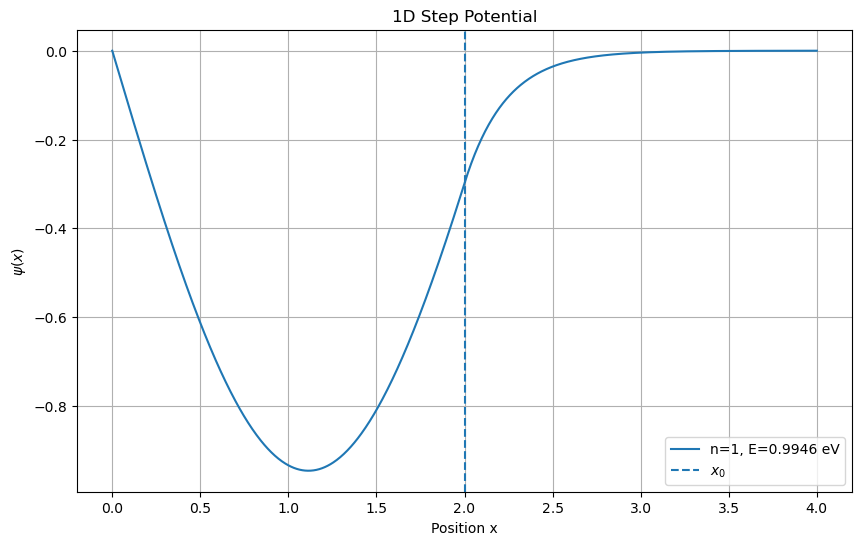

In [26]:
x0 = 2
state_number = 0
x, phi, energy = solve_step_potential(4, 10, x0, 1000, state_number)

plt.figure(figsize=(10,6))
plt.plot(x, phi,label=f"n={state_number+1}, E={energy:.4f} eV")
plt.axvline(x0, linestyle="--", label=r"$x_0$")
plt.xlabel("Position x")
plt.ylabel(r"$\psi(x)$")
plt.title("1D Step Potential")
plt.legend()
plt.grid(True)
plt.show()

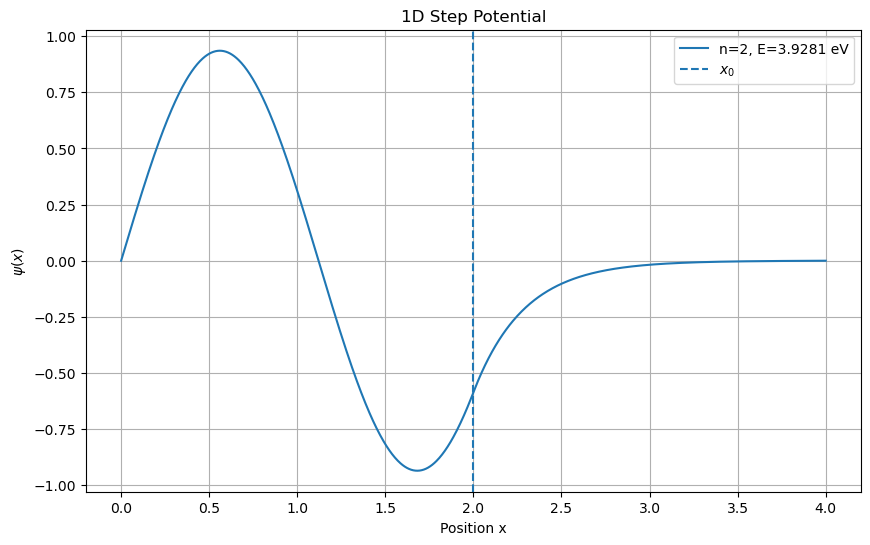

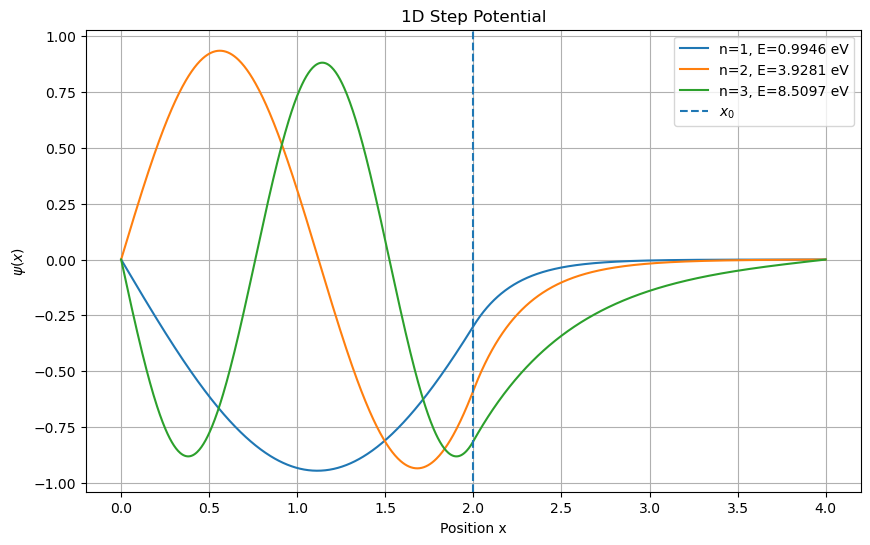

In [29]:
plt.figure(figsize=(10,6))

for i in range(3):
    x, phi, energy = solve_step_potential(4, 10, 2, 1000, i)
    plt.plot(x, phi, label=f"n={i+1}, E={energy:.4f} eV")

plt.axvline(2, linestyle="--", label=r"$x_0$")
plt.xlabel("Position x")
plt.ylabel(r"$\psi(x)$")
plt.title("1D Step Potential")
plt.legend()
plt.grid(True)
plt.show()